In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
# Oppgave 1 
Grc_df = pd.read_csv("./Grocery_dataset.csv") 

In [3]:
Grc_df.shape # gitt i mengden rader, og kolonner henholdsvis

(5000, 12)

In [4]:
print(Grc_df.head(10))

  Item_Identifier  Item_Weight Item_Fat_Content  Item_Visibility  \
0           FDA15        9.300          Low Fat         0.016047   
1           DRC01        5.920          Regular         0.019278   
2           FDN15       17.500          Low Fat         0.016760   
3           FDX07       19.200          Regular         0.000000   
4           NCD19        8.930          Low Fat         0.000000   
5           FDP36       10.395          Regular         0.000000   
6           FDO10       13.650          Regular         0.012741   
7           FDP10          NaN          Low Fat         0.127470   
8           FDH17       16.200          Regular         0.016687   
9           FDU28       19.200          Regular         0.094450   

               Item_Type  Item_MRP Outlet_Identifier  \
0                  Dairy  249.8092            OUT049   
1            Soft Drinks   48.2692            OUT018   
2                   Meat  141.6180            OUT049   
3  Fruits and Vegetables  1

In [5]:
print(Grc_df.tail(10))

     Item_Identifier  Item_Weight Item_Fat_Content  Item_Visibility  \
4990           FDE46        18.60          Low Fat         0.015859   
4991           NCQ53        17.60          Low Fat         0.018905   
4992           NCN42        20.25          Low Fat         0.014281   
4993           DRH11         5.98          Low Fat         0.075675   
4994           NCI42        18.75          Low Fat         0.010382   
4995           FDT07         5.82          Regular         0.077476   
4996           DRL60         8.52          Low Fat         0.027059   
4997           FDG20        15.50          Regular         0.126200   
4998           FDF56        16.70          Regular         0.119462   
4999           FDV33         9.60          Regular         0.027455   

                  Item_Type  Item_MRP Outlet_Identifier  \
4990            Snack Foods  152.9366            OUT017   
4991     Health and Hygiene  234.6590            OUT046   
4992              Household  148.0418    

In [6]:
# Oppgave 2
Grc_df.isna().sum() # Gir summen for alle null verdier kolonner "Item_Weight" har 818 null og "Outlet_Size" har 1439 null

Item_Identifier                 0
Item_Weight                   818
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  1439
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

<Axes: xlabel='Item_Weight', ylabel='Count'>

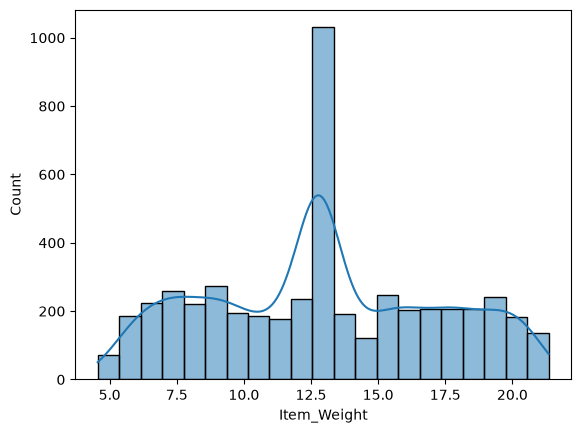

In [7]:
Grc_df["Item_Weight"] = Grc_df["Item_Weight"].replace(np.nan, Grc_df["Item_Weight"].median())
sns.histplot(Grc_df['Item_Weight'], kde=True, bins=21)

In [8]:
Grc_df["Outlet_Size"] = Grc_df["Outlet_Size"].replace(np.nan,"Medium") # Går med antakelsen at de fleste er medium...

<Axes: xlabel='Outlet_Size', ylabel='Count'>

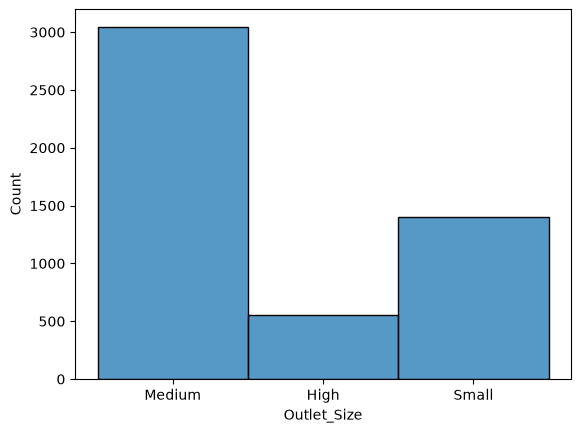

In [9]:
sns.histplot(Grc_df['Outlet_Size'], kde=False, bins=20)

In [10]:
# Oppgave 3
print(Grc_df["Outlet_Size"].unique()) # Det er tre unike 

<StringArray>
['Medium', 'High', 'Small']
Length: 3, dtype: str


In [11]:
print(Grc_df["Outlet_Size"].max())

Small


In [12]:
print(Grc_df["Outlet_Size"].min())

High


In [13]:
# Oppgave 4
print(Grc_df["Item_Fat_Content"].unique()) # Problem oppstår ved at det er flere navn/typer som beskriver samme verdi feks LF og Low Fat

<StringArray>
['Low Fat', 'Regular', 'low fat', 'LF', 'reg']
Length: 5, dtype: str


In [14]:
Grc_df["Item_Fat_Content"] = Grc_df["Item_Fat_Content"].replace('low fat', "Low Fat")


In [15]:
Grc_df["Item_Fat_Content"] = Grc_df["Item_Fat_Content"].replace('LF', "Low Fat")


In [16]:
Grc_df["Item_Fat_Content"] = Grc_df["Item_Fat_Content"].replace('reg', "Regular")


In [17]:
print(Grc_df["Item_Fat_Content"].unique())

<StringArray>
['Low Fat', 'Regular']
Length: 2, dtype: str


In [18]:
# Oppgave 5
Grc_New_df = Grc_df.drop(Grc_df.columns[[0,6]], axis=1)

In [19]:
Grc_New_df.shape # Bekreftelse for at 2 kolonner er blitt borte

(5000, 10)

In [20]:
Grc_New_df["Outlet_Type"].unique()

<StringArray>
['Supermarket Type1', 'Supermarket Type2', 'Grocery Store',
 'Supermarket Type3']
Length: 4, dtype: str

In [25]:
Sub_Type1 = Grc_New_df.loc[Grc_New_df["Outlet_Type"] == "Supermarket Type1"]

In [37]:
print(type(Sub_Type1)) # Confirmation at dette fremdeles er et df
Sub_Type1.shape

<class 'pandas.DataFrame'>


(3328, 10)

In [32]:
Sub_Type2 = Grc_New_df.loc[Grc_New_df["Outlet_Type"] == "Supermarket Type2"]

In [38]:
print(type(Sub_Type2)) # Samme confirmation også bruker vi property shape for å sjekke hva som er inni df
Sub_Type2.shape

<class 'pandas.DataFrame'>


(526, 10)

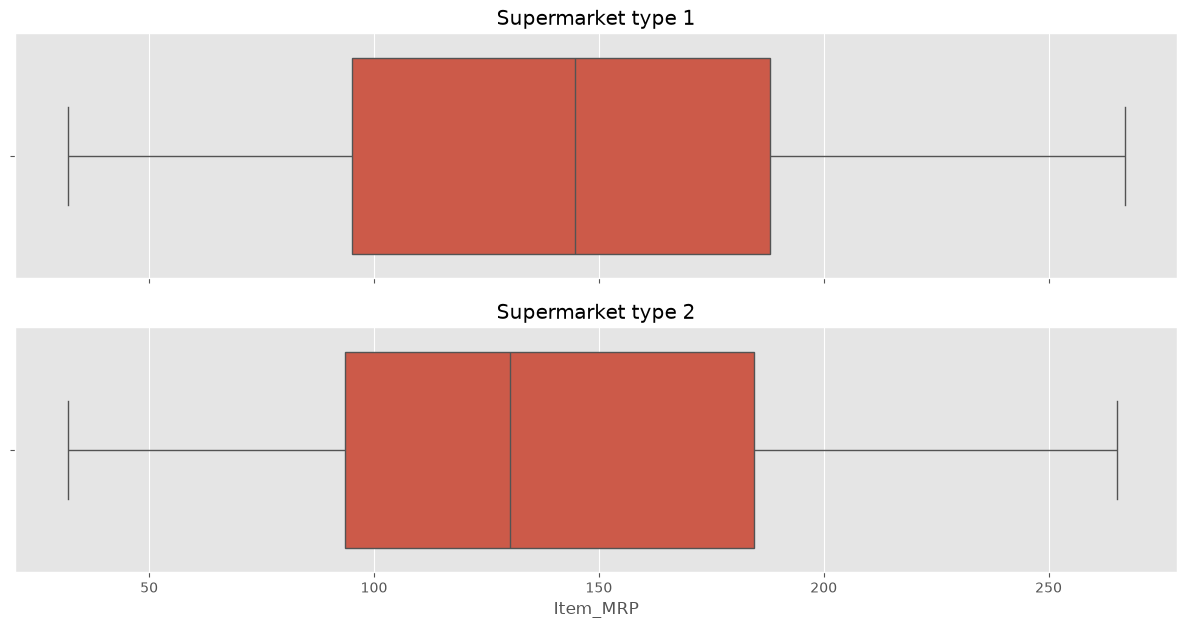

In [67]:
# Oppgave 7
plt.style.use("ggplot") 
fig, axes = plt.subplots(2 , 1, figsize=(15,7), sharex=True) # Oppretter matrisen for chartsa 

# Første chart opprettes og legges til i første rad i matrisen
sns.boxplot(x=Sub_Type1["Item_MRP"], ax=axes[0])
axes[0].set_title("Supermarket type 1")

# Samme bare i rad to
sns.boxplot(x=Sub_Type2["Item_MRP"], ax=axes[1])
axes[1].set_title("Supermarket type 2")

plt.show() # Viser matrisen

# Det er ingen outliers 
# Det er Supermarket Type 1 som har høyest meadian

In [68]:
Grc_Concat_df = pd.concat([Sub_Type1, Sub_Type2], ignore_index=True).sort_values(by="Item_Outlet_Sales")

In [72]:
# Oppgave 8
print(Grc_Concat_df["Outlet_Location_Type"].head(1)) # Tier 3 er den med laveste salg siden vi sortere stigende

1582    Tier 3
Name: Outlet_Location_Type, dtype: str
